In [3]:
import os
os.chdir(r'D:\neurofive ml intern')
print(os.getcwd())

d:\neurofive ml intern


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 891, Columns: 12


## Data Story: First Look at the Titanic Dataset

The dataset contains 891 rows and 12 columns. Two columns have significant 
missing values: `Age` (177 missing, ~20%) and `Cabin` (687 missing, ~77% — 
mostly empty and likely to be dropped or engineered differently). `Embarked` 
has just 2 missing values, easy to handle. Numerical columns include `Age`, 
`Fare`, `SibSp`, and `Parch`, while `PassengerId`, `Survived`, and `Pclass` 
are technically stored as integers but actually represent categories, not 
quantities. True categorical/text columns are `Name`, `Sex`, `Ticket`, 
`Cabin`, and `Embarked`. The `Fare` column also shows a wide spread (0 to 
512), suggesting outliers worth investigating later.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [11]:
# Fill missing Age with median (robust to outliers, unlike mean)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has too many missing values (77%) to reliably fill — drop it
df = df.drop(columns=['Cabin'])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Handling Missing Values

I filled `Age` with the median instead of the mean since median is 
less sensitive to outliers, and age distributions often skew. 
`Embarked` had only 2 missing values, so I filled those with the most 
frequent port. `Cabin` was missing for ~77% of passengers, so filling 
it would introduce more noise than signal — I dropped the column instead.

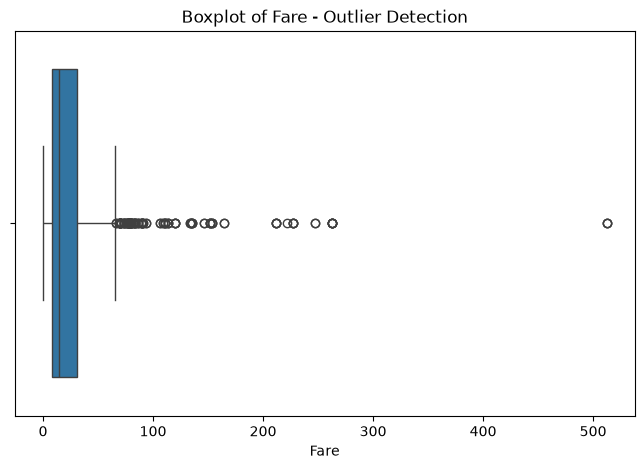

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

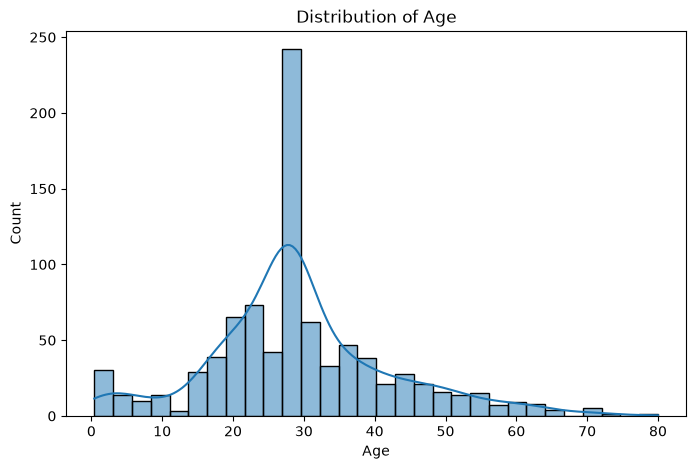

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

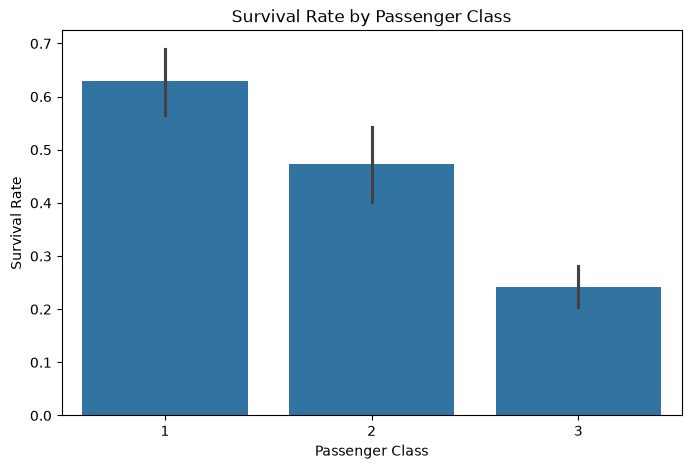

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

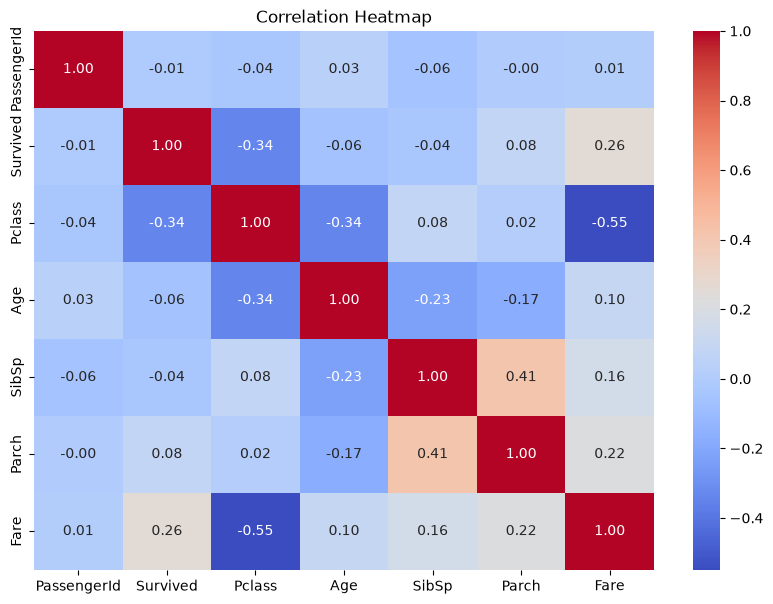

In [15]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Which feature most affects survival?

Based on the visualizations, `Sex` and `Pclass` appear to have the 
strongest relationship with survival. The bar chart shows passengers 
in 1st class had a much higher survival rate than 3rd class, and 
historically women had priority during evacuation (the "women and 
children first" protocol), which the data reflects. `Fare` is also 
correlated with survival, but that's likely because higher fares 
correlate with higher class — not a separate effect.